In [7]:
import json
import math

files = {
    "random": "../results/random.json",
    "greedy_ovr": "../results/greedy_ovr.json",
    "greedy_f": "../results/greedy_f.json",
    "expectimax_500": "../results/expectimax_500.json",
    "expectimax_1000": "../results/expectimax_1000.json",
    "expectimax_2000": "../results/expectimax_2000.json",
}

def std(values, mean):
    return math.sqrt(sum((x - mean) ** 2 for x in values) / len(values))

results = {}
for name, filename in files.items():
    with open(filename) as f:
        data = json.load(f)
    scores = data["scores"]
    final_scores = [v["final_score"] for v in scores.values()]
    chemistries = [v["chemistry"] for v in scores.values()]

    avg_final_score = sum(final_scores) / len(final_scores)
    avg_chemistry = sum(chemistries) / len(chemistries)

    results[name] = {
        "n": len(scores),
        "avg_final_score": avg_final_score,
        "std_final_score": std(final_scores, avg_final_score),
        "avg_chemistry": avg_chemistry,
        "std_chemistry": std(chemistries, avg_chemistry),
    }

print(f"{'Abordagem':<20} {'N':>5} {'Avg Final Score':>16} {'Std Final Score':>16} {'Avg Chemistry':>14} {'Std Chemistry':>14}")
print("-" * 90)
for name, r in results.items():
    print(
        f"{name:<20} {r['n']:>5}"
        f" {r['avg_final_score']:>16.4f} {r['std_final_score']:>16.4f}"
        f" {r['avg_chemistry']:>14.4f} {r['std_chemistry']:>14.4f}"
    )

Abordagem                N  Avg Final Score  Std Final Score  Avg Chemistry  Std Chemistry
------------------------------------------------------------------------------------------
random                 100          80.9827           1.5289         2.6545         1.3985
greedy_ovr             100          85.0782           1.8565         4.1818         1.7519
greedy_f               100          87.4818           1.7971         7.1236         1.7659
expectimax_500         100          88.3273           1.5376         8.3127         1.4852
expectimax_1000        100          88.2509           1.5010         8.2036         1.4720
expectimax_2000        100          88.2327           1.4989         8.1964         1.5050


In [6]:
from itertools import combinations
from scipy import stats

files = {
    "random": "../results/random.json",
    "greedy_ovr": "../results/greedy_ovr.json",
    "greedy_f": "../results/greedy_f.json",
    "expectimax_500": "../results/expectimax_500.json",
    "expectimax_1000": "../results/expectimax_1000.json",
    "expectimax_2000": "../results/expectimax_2000.json",
}

# Carrega os valores brutos de cada abordagem
raw = {}
for name, filename in files.items():
    with open(filename) as f:
        data = json.load(f)
    scores = data["scores"]
    raw[name] = {
        "final_scores": [v["final_score"] for v in scores.values()],
        "chemistries": [v["chemistry"] for v in scores.values()],
    }

# Calcula t-student para cada par de abordagens
results_significance = {}
for a, b in combinations(raw.keys(), 2):
    t_final, p_final = stats.ttest_ind(raw[a]["final_scores"], raw[b]["final_scores"])
    t_chem,  p_chem  = stats.ttest_ind(raw[a]["chemistries"],  raw[b]["chemistries"])

    results_significance[(a, b)] = {
        "final_score": {"t": t_final, "p": p_final},
        "chemistry":   {"t": t_chem,  "p": p_chem},
    }

# Exibe os resultados
print(f"{'Par':<45} {'t (final)':>10} {'p (final)':>12} {'t (chem)':>10} {'p (chem)':>12}")
print("-" * 92)
for (a, b), r in results_significance.items():
    pair = f"{a} vs {b}"
    print(
        f"{pair:<45}"
        f" {r['final_score']['t']:>10.4f} {r['final_score']['p']:>12.4e}"
        f" {r['chemistry']['t']:>10.4f} {r['chemistry']['p']:>12.4e}"
    )

Par                                            t (final)    p (final)   t (chem)     p (chem)
--------------------------------------------------------------------------------------------
random vs greedy_ovr                            -16.9435   2.1863e-40    -6.7791   1.3568e-10
random vs greedy_f                              -27.4065   2.6208e-69   -19.7407   1.1613e-48
random vs expectimax_500                        -33.7023   5.9155e-84   -27.5979   8.7825e-70
random vs expectimax_1000                       -33.7529   4.5921e-84   -27.1931   8.9176e-69
random vs expectimax_2000                       -33.6914   6.2474e-84   -26.8400   6.8493e-68
greedy_ovr vs greedy_f                           -9.2559   3.5418e-17   -11.7674   1.3955e-24
greedy_ovr vs expectimax_500                    -13.4111   1.3377e-29   -17.8962   3.0522e-43
greedy_ovr vs expectimax_1000                   -13.2228   5.0560e-29   -17.4882   5.0492e-42
greedy_ovr vs expectimax_2000                   -13.1543   8.

### Plot de ovr e quimica

In [9]:
COLORS = {
    "random":          "#9E9E9E",
    "greedy_ovr":      "#5C9BD6",
    "greedy_f":        "#4DB8A4",
    "expectimax_500":  "#F4A460",
    "expectimax_1000": "#E07B54",
    "expectimax_2000": "#C0392B",
}

In [14]:
figsize = (12, 6)
ax_ticks_size = 12
y_label_size = 20
x_label_size = 20
labelpad_size = 10

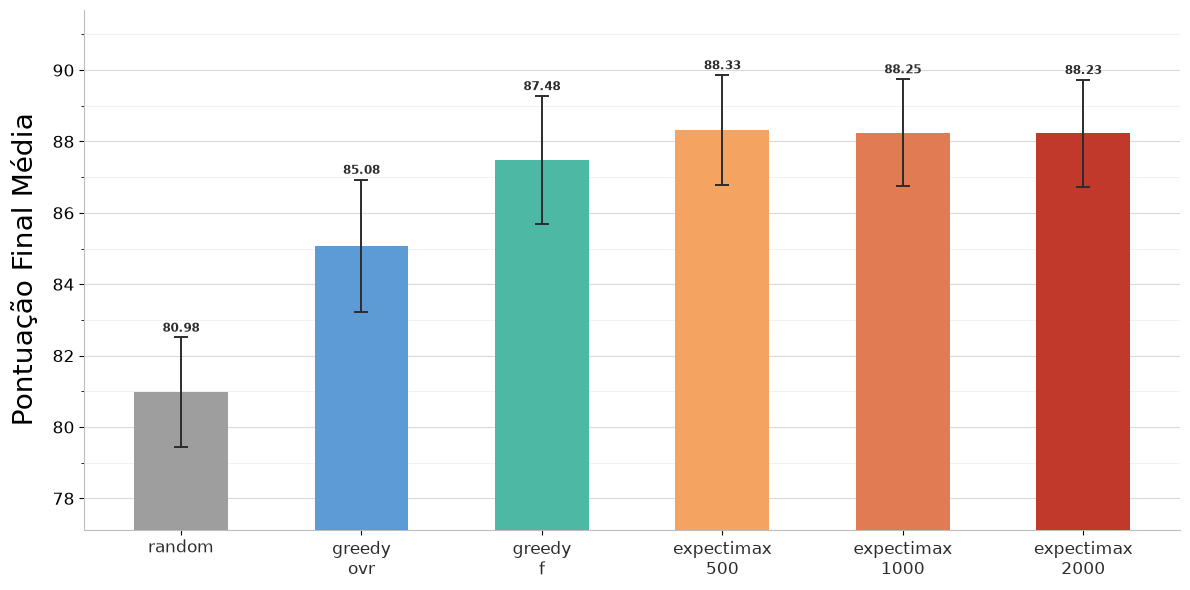

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np


labels = list(results.keys())
means  = [results[k]["avg_final_score"] for k in labels]
stds   = [results[k]["std_final_score"]  for k in labels]
x = np.arange(len(labels))

COLORS = {
    "random":          "#9E9E9E",
    "greedy_ovr":      "#5C9BD6",
    "greedy_f":        "#4DB8A4",
    "expectimax_500":  "#F4A460",
    "expectimax_1000": "#E07B54",
    "expectimax_2000": "#C0392B",
}
BAR_W   = 0.52
ERR_KW  = dict(ecolor="#2c2c2c", elinewidth=1.4, capsize=5, capthick=1.4)

fig, ax = plt.subplots(figsize=figsize)
# fig.patch.set_facecolor("#F9F9F9")
# ax.set_facecolor("#F9F9F9")

bars = ax.bar(
    x, means,
    width=BAR_W,
    color=[COLORS[k] for k in labels],
    yerr=stds,
    error_kw=ERR_KW,
    zorder=3,
)


ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.grid(axis="y", which="major", color="#DADADA", linewidth=0.8, zorder=0)
ax.grid(axis="y", which="minor", color="#EBEBEB", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)


for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.08,
        f"{mean:.2f}",
        ha="center", va="bottom",
        fontsize=8.5, color="#2c2c2c", fontweight="bold",
    )


ax.set_xticks(x)
ax.set_xticklabels(
    [l.replace("_", "\n") for l in labels],
    fontsize=9.5, color="#2c2c2c",
)
ax.set_ylabel("Pontuação Final Média", fontsize=y_label_size, labelpad=labelpad_size)



ax.set_ylim(
    min(means) - max(stds) - 2,
    max(means) + max(stds) + 1.5,
)


for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#BDBDBD")
ax.spines["bottom"].set_color("#BDBDBD")
ax.tick_params(labelsize=ax_ticks_size)

plt.tight_layout()
plt.savefig("plot_final_score.png", dpi=150, bbox_inches="tight")
plt.show()

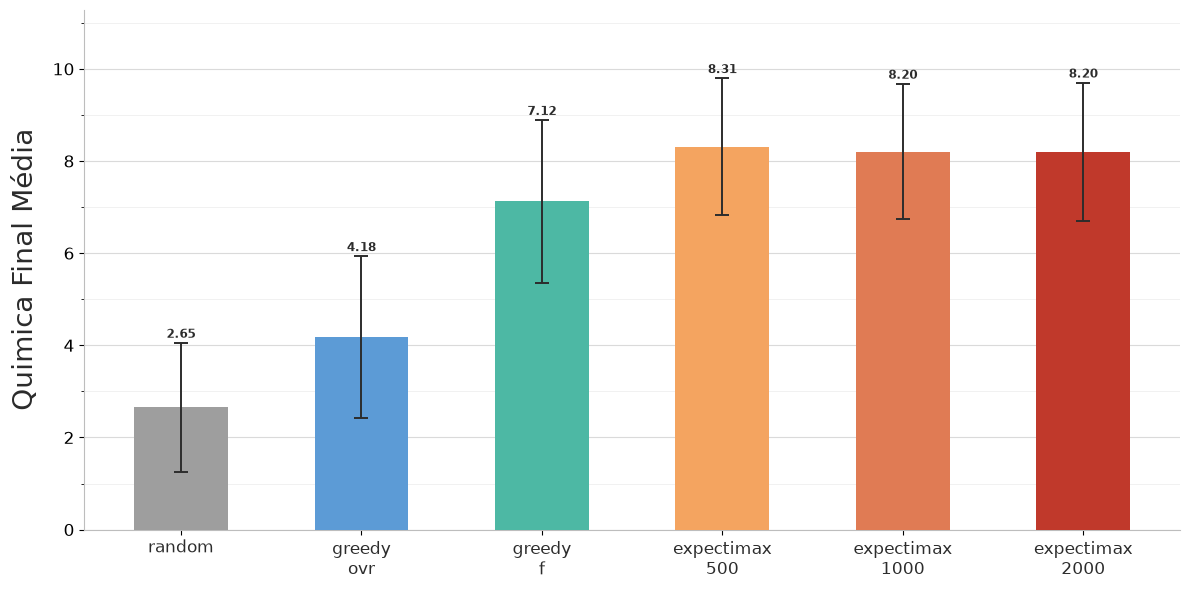

In [18]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np




labels = list(results.keys())
means  = [results[k]["avg_chemistry"] for k in labels]
stds   = [results[k]["std_chemistry"] for k in labels]

x = np.arange(len(labels))

BAR_W  = 0.52
ERR_KW = dict(ecolor="#2c2c2c", elinewidth=1.4, capsize=5, capthick=1.4)

fig, ax = plt.subplots(figsize=figsize)


bars = ax.bar(
    x, means,
    width=BAR_W,
    color=[COLORS[k] for k in labels],
    yerr=stds,
    error_kw=ERR_KW,
    zorder=3,
)

ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
ax.grid(axis="y", which="major", color="#DADADA", linewidth=0.8, zorder=0)
ax.grid(axis="y", which="minor", color="#EBEBEB", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# valor no topo de cada barra
for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.05,
        f"{mean:.2f}",
        ha="center", va="bottom",
        fontsize=8.5, color="#2c2c2c", fontweight="bold",
    )

# ── rótulos e títulos ─────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(
    [l.replace("_", "\n") for l in labels],
    fontsize=9.5, color="#2c2c2c",
)
ax.set_ylabel("Quimica Final Média", fontsize=y_label_size, color="#2c2c2c", labelpad=labelpad_size)


ax.set_ylim(
    max(0, min(means) - max(stds) - 1),
    max(means) + max(stds) + 1.2,
)


for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#BDBDBD")
ax.spines["bottom"].set_color("#BDBDBD")
ax.tick_params(labelsize=ax_ticks_size)

plt.tight_layout()
plt.savefig("plot_chemistry.png", dpi=150, bbox_inches="tight")
plt.show()

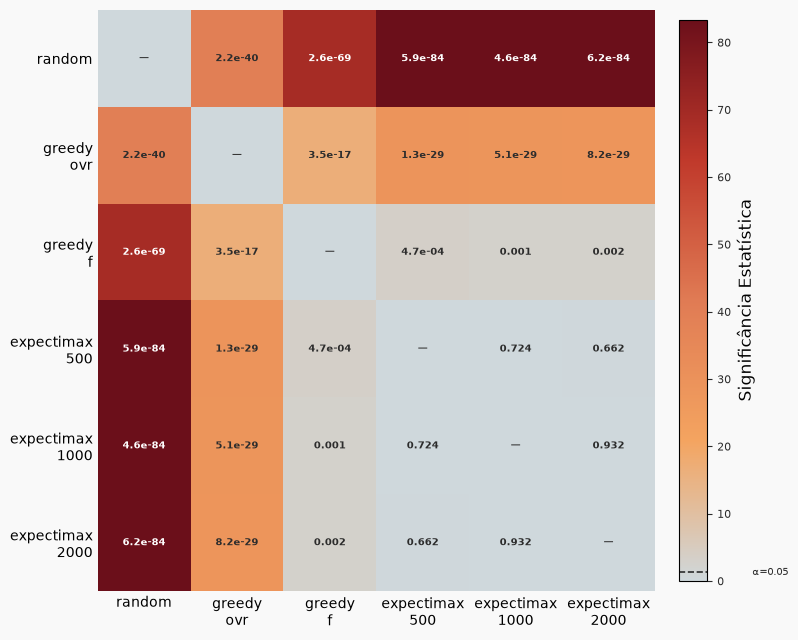

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ── results_significance já calculado pelo significance.py ────────────────────
# Estrutura: {(a, b): {"final_score": {"t": ..., "p": ...}, "chemistry": {...}}}

labels = [
    "random",
    "greedy_ovr",
    "greedy_f",
    "expectimax_500",
    "expectimax_1000",
    "expectimax_2000",
]
n = len(labels)

def build_matrix(results_significance, metric):
    """Monta matriz n×n de p-values para a métrica indicada ('final_score' ou 'chemistry')."""
    idx = {name: i for i, name in enumerate(labels)}
    matrix = np.full((n, n), np.nan)
    np.fill_diagonal(matrix, 1.0)          # diagonal = p=1 (mesma abordagem)
    for (a, b), r in results_significance.items():
        p = r[metric]["p"]
        i, j = idx[a], idx[b]
        matrix[i, j] = p
        matrix[j, i] = p                   # matriz simétrica
    return matrix


def plot_heatmap(matrix, title, filename):
    # escala de cor: azul acinzentado (p=1, não significativo) → vinho escuro (p≈0)
    # ordem: menor valor (0) → azul; maior valor (log alto) → vinho escuro
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "sig", ["#CFD8DC", "#F4A460", "#E07B54", "#C0392B", "#6B0F1A"], N=512
    )
    # log10 invertido: p pequeno → valor alto → cor escura
    log_matrix = -np.log10(np.clip(matrix, 1e-100, 1.0))

    fig, ax = plt.subplots(figsize=(8, 6.5))
    fig.patch.set_facecolor("#F9F9F9")
    ax.set_facecolor("#F9F9F9")

    im = ax.imshow(log_matrix, cmap=cmap, aspect="auto",
                   vmin=0, vmax=np.nanmax(log_matrix))

    # colorbar
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Significância Estatística", fontsize=12)
    cb.ax.tick_params(colors="#2c2c2c", labelsize=8)

    # anotações: p-value bruto em cada célula
    tick_labels = [l.replace("_", "\n") for l in labels]
    for i in range(n):
        for j in range(n):
            p = matrix[i, j]
            if np.isnan(p):
                txt = ""
            elif i == j:
                txt = "—"
            elif p < 0.001:
                txt = f"{p:.1e}"
            else:
                txt = f"{p:.3f}"
            brightness = log_matrix[i, j] / (np.nanmax(log_matrix) or 1)
            color = "white" if brightness > 0.55 else "#2c2c2c"
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=7.5, color=color, fontweight="bold")

    # eixos
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tick_labels, fontsize=ax_ticks_size - 2)
    ax.set_yticklabels(tick_labels, fontsize=ax_ticks_size - 2)
    ax.tick_params(length=0)

    # linha de significância α=0.05 na colorbar
    alpha_line = -np.log10(0.05)
    cb.ax.axhline(alpha_line, color="#2c2c2c", linewidth=1.2, linestyle="--")
    cb.ax.text(2.6, alpha_line, "α=0.05", va="center",
               fontsize=7.5, color="#2c2c2c")

    

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


# ── gera os dois heatmaps ─────────────────────────────────────────────────────
matrix_final = build_matrix(results_significance, "final_score")
matrix_chem  = build_matrix(results_significance, "chemistry")

plot_heatmap(matrix_final,
             "",
             "heatmap_final_score.png")

